### Step 1: Import Libraries & API Keys

In [107]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from IPython.display import Markdown, display
import gradio as gr
import json
import random

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY is None:
    raise Exception("API key is missing !!")

client = OpenAI()

### Step 2: RAG Preparation

In [108]:
document = """

Rajan is an AI Engineer working on Social Media Analytics. He's based in Washington DC, USA. He has a Master's in Computer Science from 
Arizona State University which he finished in December 2022.

He's been working at a Startup called Artis since Januray 2023. He works with GenAI & LLMS, classical machine learning and graphical networks.

Other Career history:

Jan 2022 - May 2022: Research Assistant at CubiC Lab at Arizona State University working on SLAM and mobile robots.
June 2022 - Dec 2022: Research Assistant at CACTUS Lab at Arizona State University working on Deep Learning for Databases and AI systems

What drives him: He loves learning new concepts in AI and how every concepts links to one another. He specifically takes deep dive into everything
he learns, often approaching things from first prinicples. He strives to obtain clarity before tackling problems.

His approach: Disambiguates diffuclt problems. Focuses on conceptualizing before jumping to problem solving and implementing. 

Communication style: Very direct, friendly, and concise. 


Additional Info: 

- In 2001, Rajan was 2 years old and learning how to walk.
- Rajan knows to cook just a few dishes, but he cooks them really well.
- Rajan likes adding Pineapple to Pizzas. He likes it along with spicy toppings to add contrast to taste.
- Rajan watches a lot of football and support the English team Liverpool. He has been a liverpool fan since 2017. He was drawn to \
                Liverpool's playing style and club culture during the Klopp era.
}


"""


In [109]:
# Chunk the document
def chunk_text(text, chunk_size=500, overlap=50):
    chunks = []
    start = 0
    n = len(text)

    while start < n:
        # Naive cut point: chunk_size characters ahead of where we started.
        end = min(start + chunk_size, n)

        # Only look for a nicer cut point if this isn't the final chunk
        # (if end == n, we've already reached the end of the text, so there's nothing to adjust).
        if end < n:
            # Only accept a boundary that's in the second half of the chunk.
            # This stops us from accepting an early match (e.g. a space near
            # the start) that would make the chunk much smaller than intended.
            half = start + chunk_size // 2
            boundary = -1

            # Try each separator in priority order: paragraph break, newline,
            # sentence end, then plain space. Stop at the first one found.
            for sep in ["\n\n", "\n", ". ", " "]:
                # Search only within the current chunk's window (start to end).
                idx = text.rfind(sep, start, end)
                if idx != -1 and idx >= half:
                    # Cut right after the separator so it stays attached
                    # to the chunk it ends, not the one it starts.
                    boundary = idx + len(sep)
                    break

            if boundary != -1:
                end = boundary
            # If no boundary qualified, we just fall back to the hard cut at chunk_size.

        chunks.append(text[start:end])

        # If this chunk reached the end of the text, we're done.
        if end >= n:
            break

        # Start the next chunk `overlap` characters before this one ended,
        # so consecutive chunks share some context.
        start = end - overlap

    return chunks

In [110]:
chunks = chunk_text(document, chunk_size = 100, overlap = 20)
len(chunks)

24

In [111]:
# Generate embeddings for all chunks

response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = chunks
)

embeddings = [item.embedding for item in response.data]

In [112]:
from pprint import pprint
# Verify embeddings
print(f"Generated {len(embeddings)} embeddings")
print(f"Each embedding has {len(embeddings[0])} dimensions")

Generated 24 embeddings
Each embedding has 1536 dimensions


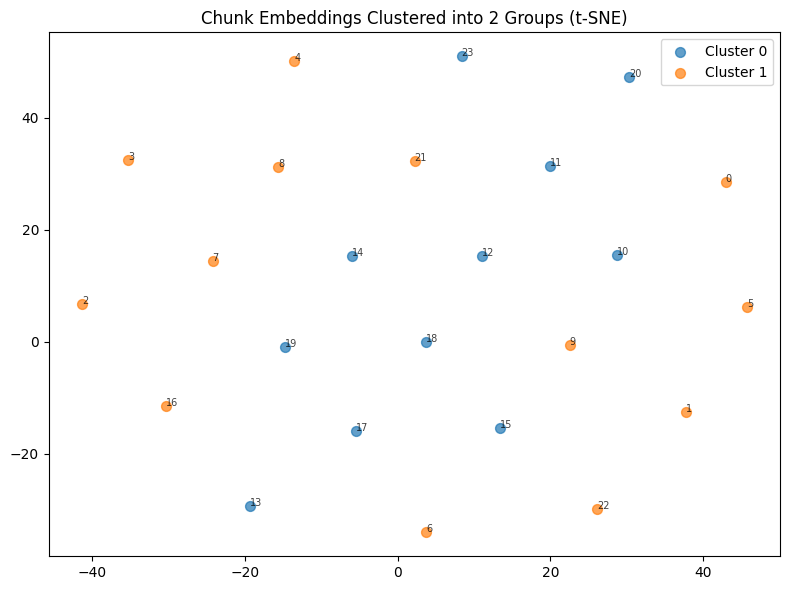

Cluster 0 (11 chunks):
The common theme of this cluster revolves around a deeply analytical and systematic approach to problem-solving, emphasizing the importance of understanding concepts at a fundamental level before taking action. Additionally, there are personal insights into Rajan's character, highlighting his direct communication style, culinary skills, and interests, which provide a glimpse into his personality beyond his analytical tendencies.

Cluster 1 (13 chunks):
The common theme of this cluster revolves around Rajan, an AI Engineer based in Washington DC, who has a strong educational background in computer science and hands-on experience in artificial intelligence, particularly in areas such as social media analytics and deep learning. The text also touches on his professional journey, including his roles as a research assistant during his studies and his current position in a startup, as well as some personal interests, such as being a Liverpool football fan.



In [113]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE


reduced = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)-1)).fit_transform(np.array(embeddings))

# Cluster the chunks into 2 groups based on their embeddings (not the
# 2D t-SNE projection, since clustering on the full embedding is more
# faithful to the actual semantic similarity between chunks).
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(np.array(embeddings))

# Plot the same 2D t-SNE points as before, colored by cluster.
plt.figure(figsize=(8, 6))
colors = ["tab:blue", "tab:orange"]
for cluster_id in range(2):
    mask = cluster_labels == cluster_id
    plt.scatter(
        reduced[mask, 0], reduced[mask, 1],
        color=colors[cluster_id],
        alpha=0.7, s=50,
        label=f"Cluster {cluster_id}"
    )

for i, (x, y) in enumerate(reduced):
    plt.annotate(str(i), (x, y), fontsize=7, alpha=0.75)

plt.title("Chunk Embeddings Clustered into 2 Groups (t-SNE)")
plt.legend()
plt.tight_layout()
plt.show()

# Ask gpt-4o-mini to describe what each cluster is about, based on the
# chunks that landed in it.
for cluster_id in range(2):
    cluster_chunks = [chunks[i] for i in range(len(chunks)) if cluster_labels[i] == cluster_id]
    combined_text = "\n---\n".join(cluster_chunks)

    description_response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "user",
                "content": (
                    "The following are text chunks that were grouped together into "
                    "the same cluster based on their semantic similarity. In 2-3 "
                    "sentences, describe the common theme or topic of this cluster:\n\n"
                    f"{combined_text}"
                )
            }
        ]
    )

    print(f"Cluster {cluster_id} ({len(cluster_chunks)} chunks):")
    print(description_response.choices[0].message.content)
    print()


In [114]:
# Initialize ChromaDB and Store Vectors

import chromadb

# Initialize chromaDB Client (persistent storage)
chroma_client = chromadb.PersistentClient(path = "./chroma_db_twin")

# Initialize chromaDB Client (in-memory storage)
# Initialize chromaDB Client (cloud storage)

collection = chroma_client.get_or_create_collection(name="netflix_culture") # get or create -> either create if it doesnt exist or fetch it if it does exit

# Empty the collection before adding new data 
if collection.get()['ids']:
    collection.delete(collection.get()['ids'])

pprint(collection.get())

{'data': None,
 'documents': [],
 'embeddings': None,
 'ids': [],
 'included': ['metadatas', 'documents'],
 'metadatas': [],
 'uris': None}


In [115]:
# Prepare data for storage

ids = [f"chunk_{i}" for i in range(len(chunks))]
metadatas = [{"source": "netflix_culture_pdf", "chunk_index": i} for i in range(len(chunks))] 

collection.add(
    ids = ids,
    embeddings=embeddings,
    documents=chunks,
    metadatas=metadatas
)

pprint(collection.get())

{'data': None,
 'documents': ['\n'
               '\n'
               'Rajan is an AI Engineer working on Social Media Analytics. '
               "He's based in Washington DC, USA. ",
               "Washington DC, USA. He has a Master's in Computer Science "
               'from \n',
               'puter Science from \n'
               'Arizona State University which he finished in December 2022.\n'
               '\n',
               ' in December 2022.\n'
               '\n'
               "He's been working at a Startup called Artis since Januray "
               '2023. ',
               'since Januray 2023. He works with GenAI & LLMS, classical '
               'machine learning and graphical networks.\n'
               '\n',
               'raphical networks.\n'
               '\n'
               'Other Career history:\n'
               '\n'
               'Jan 2022 - May 2022: Research Assistant at CubiC Lab at ',
               'ant at CubiC Lab at Arizona State University wo

In [116]:
# Test Retrieval

# Genreate embedding for a test query

test_query = "Italian food"
# test_query2 = "teamwork and collaborations"

#Embed the test query using the same model we used for the chunks to ensure compatibility
#Tip: convert the query into a list

response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = [test_query]
)

query_embedding = [response.data[0].embedding]

# Search ChromaDB
# convert query embedding to list

results = collection.query(
    query_embeddings=query_embedding,
    n_results=2,
    # include=['documents','metadatas', 'embeddings']
)

pprint(results)

{'data': None,
 'distances': [[1.2864768505096436, 1.3391834497451782]],
 'documents': [['ineapple to Pizzas. He likes it along with spicy toppings to '
                'add contrast to taste.\n',
                's them really well.\n'
                '- Rajan likes adding Pineapple to Pizzas. ']],
 'embeddings': None,
 'ids': [['chunk_19', 'chunk_18']],
 'included': ['metadatas', 'documents', 'distances'],
 'metadatas': [[{'chunk_index': 19, 'source': 'netflix_culture_pdf'},
                {'chunk_index': 18, 'source': 'netflix_culture_pdf'}]],
 'uris': None}


In [117]:
tools = []

### Step 3a: Add tool calling functionality (Pushover)

In [118]:
pushover_user = os.getenv("PUSHOVER_USER")
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_url = "https://api.pushover.net/1/messages.json"

# Create Send notification function
import requests

def send_notification(message: str):
    payload = {"user": pushover_user, "token": pushover_token, "message": message}
    requests.post(pushover_url, data=payload)


# Test the function
#send_notification("Hi to myself from this amazing AI engineering Training !!")


send_notification_function = {
    "name": "send_notification",
    "description": "Sends a push notification to the real-world version of you via Pushover on mobile. Use this if the user needs to alert the real-world version of you.",
    "parameters": {
        "type": "object",
        "properties": {
            "message": {
                "type": "string",
                "description": "The notification message to send to the user's device"
            }
        },
        "required": ['message']
    }
}

# Add Pushover to the list of tools for the LLM
tools.append(
    {"type": "function", "function": send_notification_function},
    #{Tool 2}
    #{Tool 3} .....
    )

### Step 3b: Add Dice rolling functionality

In [119]:
# Simulate rolling a single die
def dice_roll():
    result = random.randint(1,6)
    return result


# Describe function for LLM
dice_roll_function = {
    "name": "dice_roll",
    "description": "Simulates rolling a single six-sided die and returns the result. Use this when the user wants to roll a die for games, decisions, or random number generation.",
    "parameters":{
        "type": "object",
        "properties": {},
        "required": []
    }
}

# Add function to list of tools of LLM
tools.append({"type" : "function", "function" : dice_roll_function})

### Step 4: Function to handle LLM tool calls

In [120]:
def handle_tool_call(tool_calls):
    tool_call_results = []
    for tool_call in tool_calls:
        function_name = tool_call.function.name
        args = json.loads(tool_call.function.arguments)
        # print(f"Calling function {function_name}") # For future debugging

        # Route to the appropriate function based on function_name
        if function_name == "send_notification":
            send_notification(args['message'])
            content = f"Sent notification: {args['message']}"
        
        # elif function_name == "func":
            # content = func2(args['message'])

        elif function_name == "dice_roll":
            content = f"Rolled: {dice_roll()}"

        else:
            content = f"Unknown function: {function_name}"

        tool_call_result = {
            "role" : "tool",
            "tool_call_id" : tool_call.id,
            "content" : content
        }
        tool_call_results.append(tool_call_result)
    return tool_call_results

### Step 5: Function to process the Conversation Turn

In [121]:
system_message = """You are a digital Twin of Rajan. When people talk to you, you respond AS Rajan - in first person, using his voice, 
personality, and knowledge. 

Important: Do not make things up. If you don't know an answer, say you don't know. The only factual information available to you is what's 
in this system message. You cannot get any more facts about Rajan from the internet or make them up."""



In [126]:
def respond_ai(message, history):

    # RAG

    response = client.embeddings.create(
        model = "text-embedding-3-small",
        input = [message]
    )

    query_embedding = [response.data[0].embedding]

    # Search ChromaDB
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=2
    )

    # Process the n_results=3 part
    context = "\n----\n".join(results['documents'][0])
    print(f"User message:\n {message}")
    print()
    print(f"Context this turn:\n {context}")
    system_message_enhanced = system_message + "\n\nContext:\n" + context

    #------------------------------------------------------------------------#

    # As usual
    messages = [{"role" : "system", "content" : system_message_enhanced}] + history + [{"role" : "user", "content" : message}]
    #client = OpenAI(api_key=OPENAI_API_KEY)
    response = client.chat.completions.create(
        model = "gpt-4.1-mini",
        messages=messages,
        tools=tools
    )
    # Check if model wants to call a tool
    message = response.choices[0].message


    while message.tool_calls:
        from pprint import pprint
        pprint(message.tool_calls)
        tool_call = message.tool_calls[0]

        tool_result = handle_tool_call(message.tool_calls) # Pass whole list 

        # Add info about tool call to context for LLM - ie. messages
        messages.append(message)
        messages.extend(tool_result)

        # Invoke LLM one more time to get its updated response
        response = client.chat.completions.create(
            model = "gpt-4.1-mini",
            messages=messages,
            tools = tools 
        )
        message = response.choices[0].message

        #NOTE: Maybe consider adding protection from infinite consecutive tool calling

    return(message.content)

    # reply = response.choices[0].message.content
    # return reply


### Step 6: Launch Gradio 

In [ ]:
gr.ChatInterface(fn=respond_ai, type="messages").launch(inbrowser=True)

Running on local URL:  http://127.0.0.1:7878

To create a public link, set `share=True` in `launch()`.


User message:
 Hi ! Who are you ?
User message:
 What do you think of Italian food ?
